In [ ]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/Advanced Machine Learning/pokemon.csv"

df = pd.read_csv(file_path)

print("Shape:", df.shape)
df.head()

MessageError: Error: credential propagation was unsuccessful

In [ ]:
stat_cols = ["hp","atk","def","spatk","spdef","speed","total"]
df[stat_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
hp,1025.0,70.184390,26.631054,1.0,50.0,68.0,85.0,255.0
atk,1025.0,77.521951,29.782541,5.0,55.0,75.0,100.0,181.0
def,1025.0,72.507317,29.286972,5.0,50.0,70.0,90.0,230.0
spatk,1025.0,70.080976,29.658378,10.0,47.0,65.0,90.0,173.0
spdef,1025.0,70.205854,26.639329,20.0,50.0,67.0,86.0,230.0
speed,1025.0,67.186341,28.717227,5.0,45.0,65.0,88.0,200.0
total,1025.0,427.686829,112.770735,175.0,325.0,450.0,508.0,720.0


In [ ]:
import matplotlib.pyplot as plt


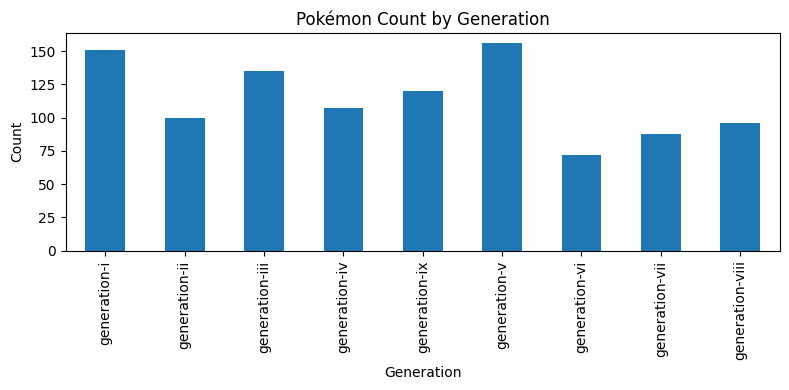

In [ ]:
plt.figure(figsize=(8,4))
df["generation"].value_counts(dropna=False).sort_index().plot(kind="bar")
plt.title("Pokémon Count by Generation")
plt.xlabel("Generation")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


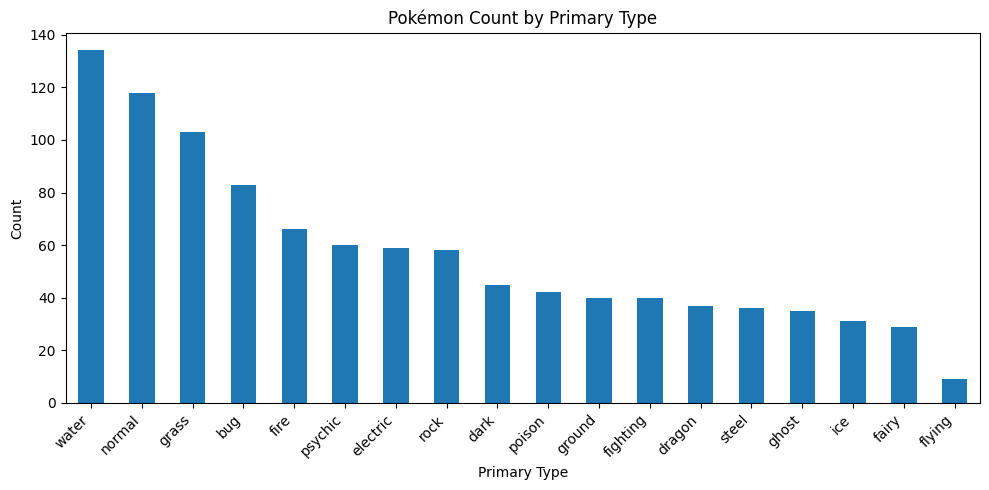

In [ ]:
plt.figure(figsize=(10,5))
df["type1"].value_counts().plot(kind="bar")
plt.title("Pokémon Count by Primary Type")
plt.xlabel("Primary Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


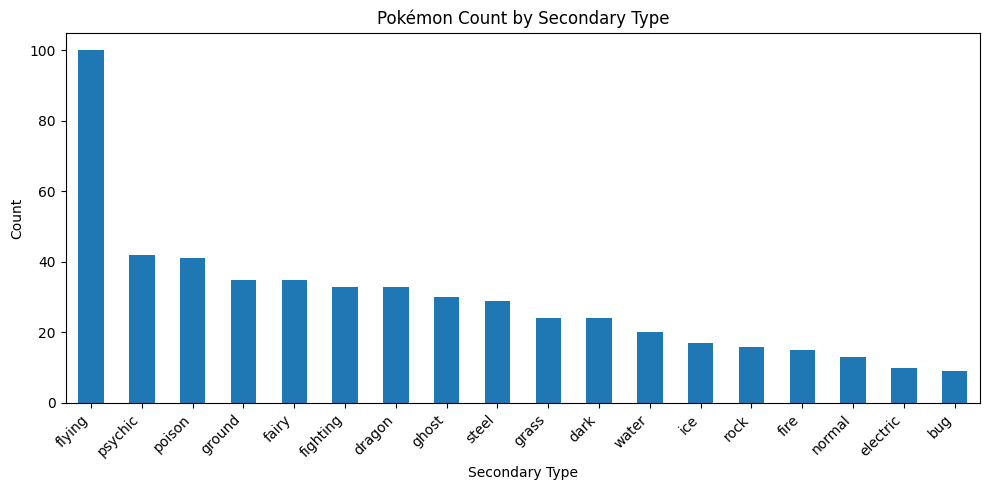

In [ ]:
plt.figure(figsize=(10,5))
(df["type2"].value_counts()
   .drop(labels=["None"], errors="ignore")
   .plot(kind="bar"))
plt.title("Pokémon Count by Secondary Type")
plt.xlabel("Secondary Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
import seaborn as sns


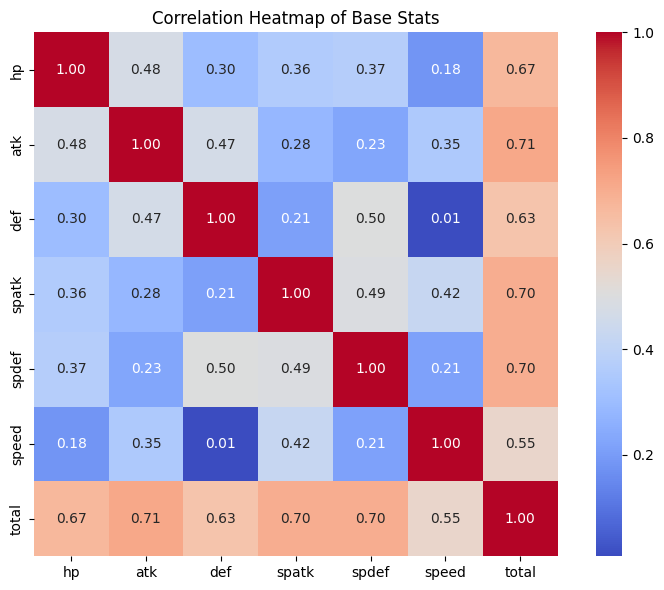

In [ ]:
plt.figure(figsize=(8,6))
corr = df[["hp","atk","def","spatk","spdef","speed","total"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap of Base Stats")
plt.tight_layout()
plt.show()


In [ ]:
# Create a boolean column for legendary status
df["is_legendary"] = df["rank"].str.lower() == "legendary"

# Quick check
df["is_legendary"].value_counts()


,count
is_legendary,
False,955
True,70


/tmp/ipython-input-1944660790.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="is_legendary", y="total", palette="Set2")


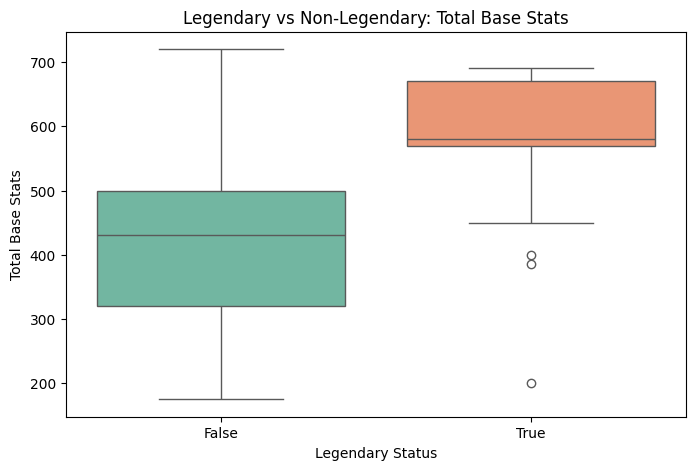

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="is_legendary", y="total", palette="Set2")
plt.title("Legendary vs Non-Legendary: Total Base Stats")
plt.xlabel("Legendary Status")
plt.ylabel("Total Base Stats")
plt.show()


In [ ]:
# Compare mean stats side by side
stats_cols = ["hp","atk","def","spatk","spdef","speed","total"]
df.groupby("is_legendary")[stats_cols].mean().round(1)


,hp,atk,def,spatk,spdef,speed,total
is_legendary,,,,,,,
False,68.3,75.6,70.7,67.7,68.0,65.1,415.4
True,95.3,103.2,97.3,102.4,100.7,95.7,594.7


Making generation column into numerical values

In [ ]:
# Convert "generation" column (e.g., 'generation-i') into numeric generation codes

roman_map = {
    "i":1,"ii":2,"iii":3,"iv":4,"v":5,"vi":6,"vii":7,"viii":8,"ix":9
}

def parse_generation(s):
    if isinstance(s, str) and "generation-" in s.lower():
        key = s.lower().replace("generation-","")
        return roman_map.get(key, None)
    return None

df["gen_num"] = df["generation"].apply(parse_generation)

# Quick check
df[["generation","gen_num"]].head(10)


,generation,gen_num
0,generation-i,1
1,generation-i,1
2,generation-i,1
3,generation-i,1
4,generation-i,1
5,generation-i,1
6,generation-i,1
7,generation-i,1
8,generation-i,1
9,generation-i,1


In [ ]:
# Step 3: Feature Engineering

import numpy as np

# 1) Offensive Index
df["offensive_index"] = (df["atk"] + df["spatk"]) / 2

# 2) Defensive Index
df["defensive_index"] = (df["def"] + df["spdef"]) / 2

# 3) Speed-to-Power Ratio
df["speed_to_power"] = df["speed"] / df["total"]

# 4) Era Index (z-score of total stats within each generation)
df["era_index"] = df.groupby("gen_num")["total"].transform(
    lambda s: (s - s.mean()) / s.std(ddof=0)
)

# Preview new columns
df[["name","generation","atk","spatk","def","spdef","speed","total",
    "offensive_index","defensive_index","speed_to_power","era_index"]].head(10)


,name,generation,atk,spatk,def,spdef,speed,total,offensive_index,defensive_index,speed_to_power,era_index
0,bulbasaur,generation-i,49,65,49,65,45,318,57.0,57.0,0.141509,-0.900531
1,ivysaur,generation-i,62,80,63,80,60,405,71.0,71.5,0.148148,-0.026545
2,venusaur,generation-i,82,100,83,100,80,525,91.0,91.5,0.152381,1.178953
3,charmander,generation-i,52,60,43,50,65,309,56.0,46.5,0.210356,-0.990943
4,charmeleon,generation-i,64,80,58,65,80,405,72.0,61.5,0.197531,-0.026545
5,charizard,generation-i,84,109,78,85,100,534,96.5,81.5,0.187266,1.269365
6,squirtle,generation-i,48,50,65,64,43,314,49.0,64.5,0.136943,-0.940714
7,wartortle,generation-i,63,65,80,80,58,405,64.0,80.0,0.143210,-0.026545
8,blastoise,generation-i,83,85,100,105,78,530,84.0,102.5,0.147170,1.229182
9,caterpie,generation-i,30,20,35,20,45,195,25.0,27.5,0.230769,-2.136166


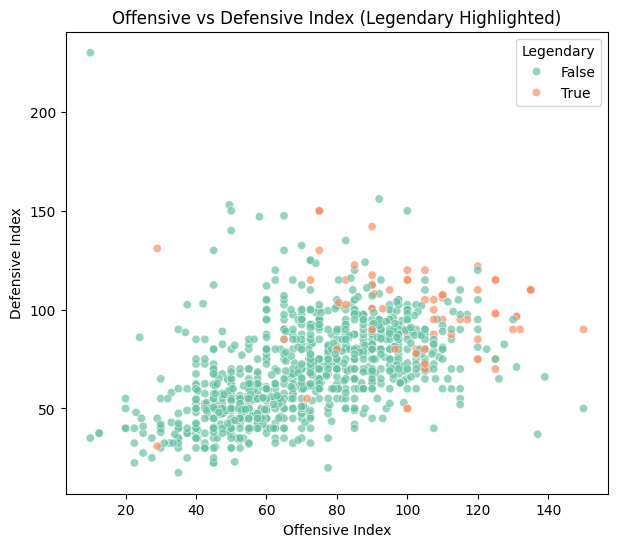

In [ ]:
# Scatterplot: Offensive vs Defensive Index
plt.figure(figsize=(7,6))
sns.scatterplot(data=df, x="offensive_index", y="defensive_index",
                hue="is_legendary", alpha=0.7, palette="Set2")
plt.title("Offensive vs Defensive Index (Legendary Highlighted)")
plt.xlabel("Offensive Index")
plt.ylabel("Defensive Index")
plt.legend(title="Legendary")
plt.show()


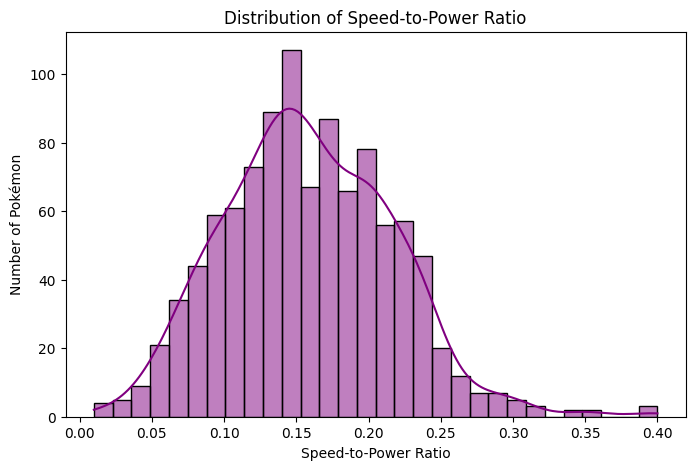

In [ ]:
# Histogram of Speed-to-Power Ratio
plt.figure(figsize=(8,5))
sns.histplot(df["speed_to_power"], bins=30, kde=True, color="purple")
plt.title("Distribution of Speed-to-Power Ratio")
plt.xlabel("Speed-to-Power Ratio")
plt.ylabel("Number of Pokémon")
plt.show()


<Figure size 1200x600 with 0 Axes>

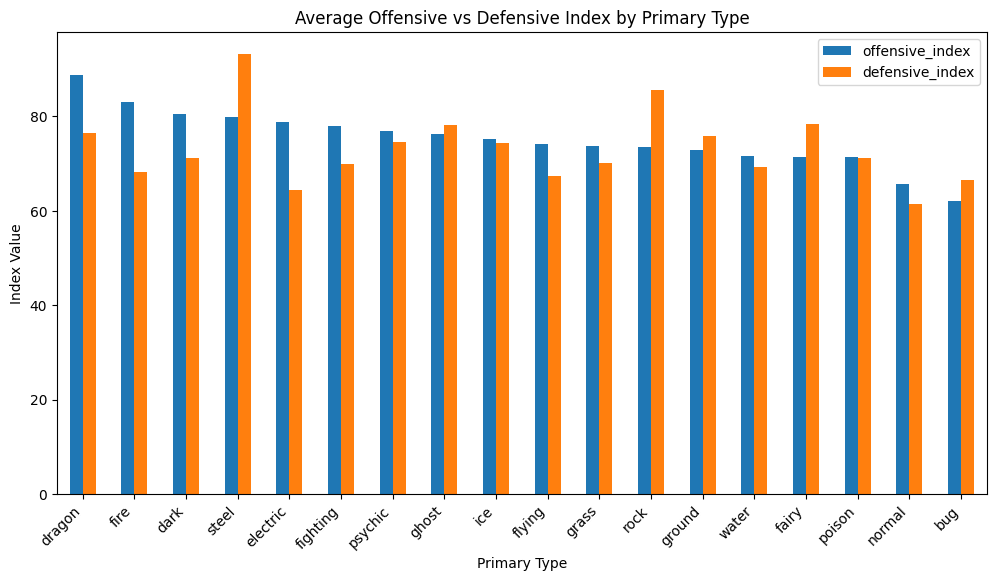

In [ ]:
# Offensive vs Defensive Index by Primary Type (average)
type_means = df.groupby("type1")[["offensive_index","defensive_index"]].mean().sort_values("offensive_index", ascending=False)

plt.figure(figsize=(12,6))
type_means.plot(kind="bar", figsize=(12,6))
plt.title("Average Offensive vs Defensive Index by Primary Type")
plt.xlabel("Primary Type")
plt.ylabel("Index Value")
plt.xticks(rotation=45, ha="right")
plt.show()


Using IQR Test to Find Outliers

In [ ]:
# Define thresholds for outliers
offense_q1, offense_q3 = df["offensive_index"].quantile([0.25, 0.75])
defense_q1, defense_q3 = df["defensive_index"].quantile([0.25, 0.75])

# IQR method: anything 1.5 * IQR outside is an outlier
offense_iqr = offense_q3 - offense_q1
defense_iqr = defense_q3 - defense_q1

outliers = df[
    (df["offensive_index"] > offense_q3 + 1.5*offense_iqr) |
    (df["offensive_index"] < offense_q1 - 1.5*offense_iqr) |
    (df["defensive_index"] > defense_q3 + 1.5*defense_iqr) |
    (df["defensive_index"] < defense_q1 - 1.5*defense_iqr)
][["name","type1","type2","offensive_index","defensive_index","is_legendary"]]

outliers.sort_values("defensive_index", ascending=False).head(15)


,name,type1,type2,offensive_index,defensive_index,is_legendary
212,shuckle,bug,rock,10.0,230.0,False
804,stakataka,rock,steel,92.0,156.0,False
410,bastiodon,rock,steel,49.5,153.0,False
376,regirock,rock,NaN,75.0,150.0,True
377,regice,ice,NaN,75.0,150.0,True
702,carbink,rock,fairy,50.0,150.0,False
378,registeel,steel,NaN,75.0,150.0,True
718,diancie,rock,fairy,100.0,150.0,False
475,probopass,rock,steel,65.0,147.5,False
747,toxapex,poison,water,58.0,147.0,False


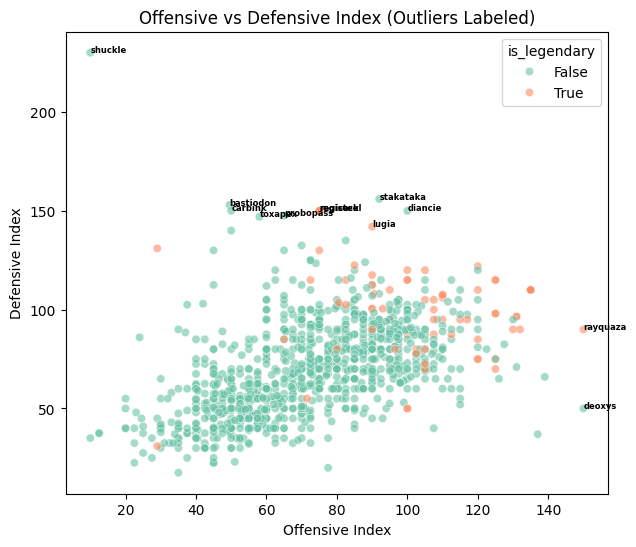

In [ ]:
plt.figure(figsize=(7,6))
sns.scatterplot(data=df, x="offensive_index", y="defensive_index",
                hue="is_legendary", alpha=0.6, palette="Set2")

# Highlight outliers with text labels
for _, row in outliers.iterrows():
    plt.text(row["offensive_index"], row["defensive_index"],
             row["name"], fontsize=6, weight="bold")

plt.title("Offensive vs Defensive Index (Outliers Labeled)")
plt.xlabel("Offensive Index")
plt.ylabel("Defensive Index")
plt.show()


In [ ]:
# Starter trios by generation
starters = {
    "Gen 1 (Kanto)": [
        ["bulbasaur","ivysaur","venusaur"],
        ["charmander","charmeleon","charizard"],
        ["squirtle","wartortle","blastoise"]
    ],
    "Gen 2 (Johto)": [
        ["chikorita","bayleef","meganium"],
        ["cyndaquil","quilava","typhlosion"],
        ["totodile","croconaw","feraligatr"]
    ],
    "Gen 3 (Hoenn)": [
        ["treecko","grovyle","sceptile"],
        ["torchic","combusken","blaziken"],
        ["mudkip","marshtomp","swampert"]
    ],
    "Gen 4 (Sinnoh)": [
        ["turtwig","grotle","torterra"],
        ["chimchar","monferno","infernape"],
        ["piplup","prinplup","empoleon"]
    ],
    "Gen 5 (Unova)": [
        ["snivy","servine","serperior"],
        ["tepig","pignite","emboar"],
        ["oshawott","dewott","samurott"]
    ],
    "Gen 6 (Kalos)": [
        ["chespin","quilladin","chesnaught"],
        ["fennekin","braixen","delphox"],
        ["froakie","frogadier","greninja"]
    ],
    "Gen 7 (Alola)": [
        ["rowlet","dartrix","decidueye"],
        ["litten","torracat","incineroar"],
        ["popplio","brionne","primarina"]
    ],
    "Gen 8 (Galar)": [
        ["grookey","thwackey","rillaboom"],
        ["scorbunny","raboot","cinderace"],
        ["sobble","drizzile","inteleon"]
    ],
    "Gen 9 (Paldea)": [
        ["sprigatito","floragato","meowscarada"],
        ["fuecoco","crocalor","skeledirge"],
        ["quaxly","quaxwell","quaquaval"]
    ]
}


In [ ]:
# Columns we’ll use
stats_cols = ["hp","atk","def","spatk","spdef","speed","total"]

def get_stage_stats(df, starters_dict, stage_idx):
    """Return average stats for all starters at a given stage (0=base, 1=middle, 2=final)."""
    results = {}
    for gen, trios in starters_dict.items():
        names = [starter[stage_idx] for starter in trios]
        gen_df = df[df["name"].str.lower().isin(names)]
        results[gen] = gen_df[stats_cols].mean()
    return pd.DataFrame(results).T


In [ ]:
# Optimized trio profile (best stat in each category across the trio)
def get_best_trio_stats(df, starters_dict, stage_idx):
    stats_cols = ["hp","atk","def","spatk","spdef","speed"]
    results = {}
    for gen, trios in starters_dict.items():
        names = [starter[stage_idx] for starter in trios]
        gen_df = df[df["name"].str.lower().isin(names)]
        results[gen] = gen_df[stats_cols].max()
    return pd.DataFrame(results).T

# Get optimized profiles
best_base   = get_best_trio_stats(df, starters, 0)
best_middle = get_best_trio_stats(df, starters, 1)
best_final  = get_best_trio_stats(df, starters, 2)

# Print nicely
print("=== Optimized Trio Profile: Base Forms ===")
display(best_base)

print("=== Optimized Trio Profile: Middle Evolutions ===")
display(best_middle)

print("=== Optimized Trio Profile: Final Evolutions ===")
display(best_final)


=== Optimized Trio Profile: Base Forms ===


,hp,atk,def,spatk,spdef,speed
Gen 1 (Kanto),45,52,65,65,65,65
Gen 2 (Johto),50,65,65,60,65,65
Gen 3 (Hoenn),50,70,50,70,55,70
Gen 4 (Sinnoh),55,68,64,61,56,61
Gen 5 (Unova),65,63,55,63,55,63
Gen 6 (Kalos),56,61,65,62,60,71
Gen 7 (Alola),68,65,55,66,56,70
Gen 8 (Galar),50,71,50,70,40,70
Gen 9 (Paldea),67,65,59,63,45,65


=== Optimized Trio Profile: Middle Evolutions ===


,hp,atk,def,spatk,spdef,speed
Gen 1 (Kanto),60,64,80,80,80,80
Gen 2 (Johto),65,80,80,80,80,80
Gen 3 (Hoenn),70,85,70,85,70,95
Gen 4 (Sinnoh),75,89,85,81,76,81
Gen 5 (Unova),90,93,75,83,75,83
Gen 6 (Kalos),61,78,95,90,70,97
Gen 7 (Alola),78,85,75,91,81,90
Gen 8 (Galar),70,86,70,95,60,94
Gen 9 (Paldea),81,85,78,90,63,83


=== Optimized Trio Profile: Final Evolutions ===


,hp,atk,def,spatk,spdef,speed
Gen 1 (Kanto),80,84,100,109,105,100
Gen 2 (Johto),85,105,100,109,100,100
Gen 3 (Hoenn),100,120,90,110,90,120
Gen 4 (Sinnoh),95,109,105,111,101,108
Gen 5 (Unova),110,123,95,108,95,113
Gen 6 (Kalos),88,107,122,114,100,122
Gen 7 (Alola),95,115,90,126,116,70
Gen 8 (Galar),100,125,90,125,75,120
Gen 9 (Paldea),104,120,100,110,75,123


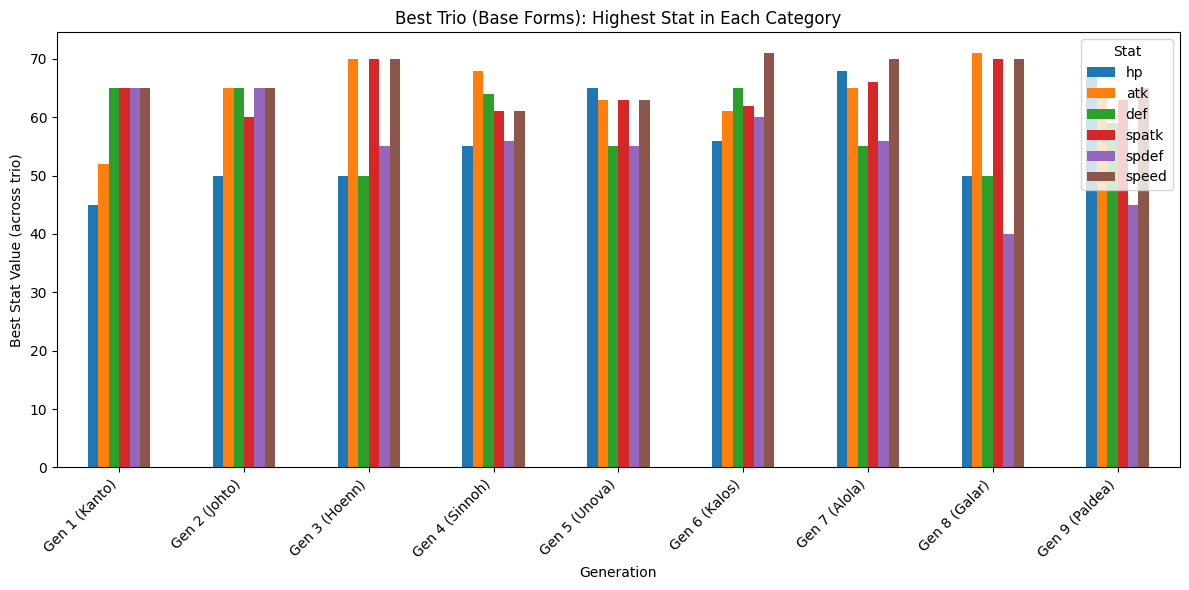

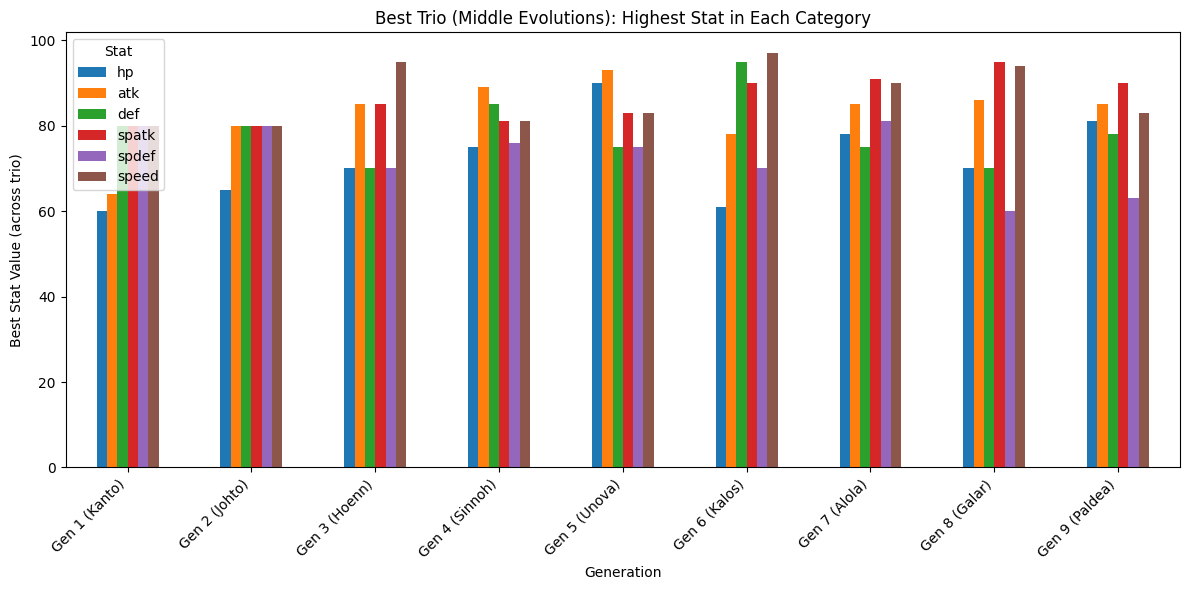

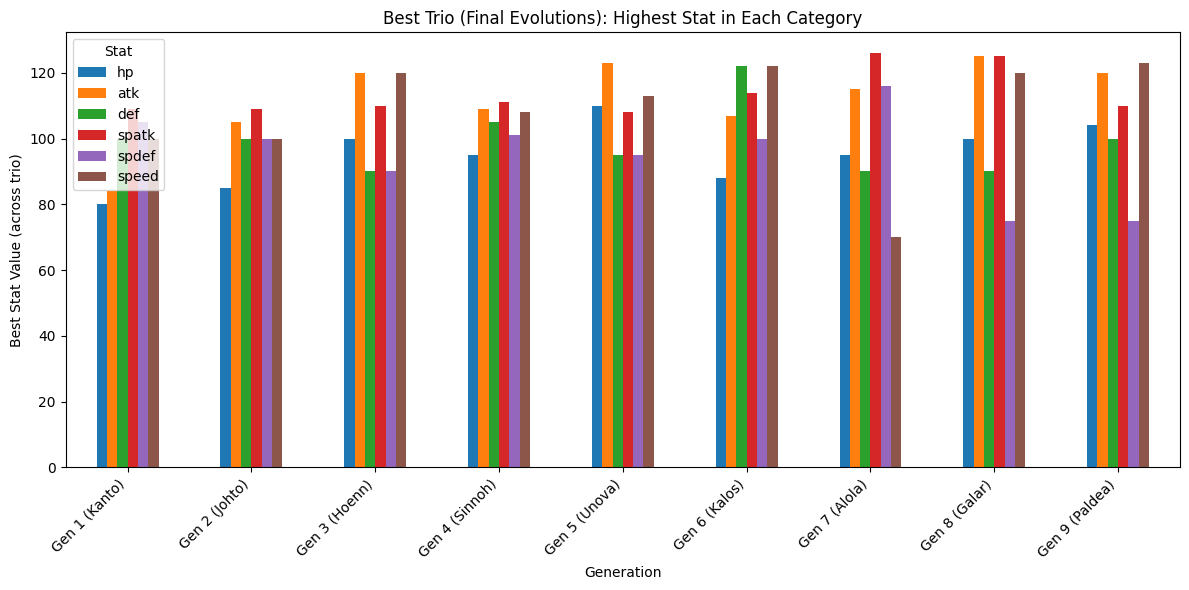

In [ ]:
# Function to calculate "best stat per category" for each trio
def get_best_trio_stats(df, starters_dict, stage_idx):
    stats_cols = ["hp","atk","def","spatk","spdef","speed"]
    results = {}
    for gen, trios in starters_dict.items():
        names = [starter[stage_idx] for starter in trios]
        gen_df = df[df["name"].str.lower().isin(names)]
        # Take the maximum stat value for each column
        results[gen] = gen_df[stats_cols].max()
    return pd.DataFrame(results).T

# Best trio stats for base, middle, final evolutions
best_base = get_best_trio_stats(df, starters, 0)
best_middle = get_best_trio_stats(df, starters, 1)
best_final = get_best_trio_stats(df, starters, 2)

# Plot helper
def plot_best(stage_stats, title):
    stage_stats.plot(kind="bar", figsize=(12,6))
    plt.title(title)
    plt.ylabel("Best Stat Value (across trio)")
    plt.xlabel("Generation")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Stat")
    plt.tight_layout()
    plt.show()

# Visualize
plot_best(best_base, "Best Trio (Base Forms): Highest Stat in Each Category")
plot_best(best_middle, "Best Trio (Middle Evolutions): Highest Stat in Each Category")
plot_best(best_final, "Best Trio (Final Evolutions): Highest Stat in Each Category")


In [ ]:
# Optimized trio profile (best stat in each category across the trio)
def get_best_trio_stats(df, starters_dict, stage_idx):
    stats_cols = ["hp","atk","def","spatk","spdef","speed"]
    results = {}
    for gen, trios in starters_dict.items():
        names = [starter[stage_idx] for starter in trios]
        gen_df = df[df["name"].str.lower().isin(names)]
        results[gen] = gen_df[stats_cols].max()
    return pd.DataFrame(results).T

# Get optimized profiles
best_base   = get_best_trio_stats(df, starters, 0)
best_middle = get_best_trio_stats(df, starters, 1)
best_final  = get_best_trio_stats(df, starters, 2)

# Add "Team Score" = sum of best stats
best_base["team_score"]   = best_base.sum(axis=1)
best_middle["team_score"] = best_middle.sum(axis=1)
best_final["team_score"]  = best_final.sum(axis=1)

# Display
print("=== Optimized Trio Profile with Team Score: Base Forms ===")
display(best_base)

print("=== Optimized Trio Profile with Team Score: Middle Evolutions ===")
display(best_middle)

print("=== Optimized Trio Profile with Team Score: Final Evolutions ===")
display(best_final)

# Optional: Which gen wins at each stage?
print("Base form strongest trio:", best_base["team_score"].idxmax(), "with", best_base["team_score"].max())
print("Middle evo strongest trio:", best_middle["team_score"].idxmax(), "with", best_middle["team_score"].max())
print("Final evo strongest trio:", best_final["team_score"].idxmax(), "with", best_final["team_score"].max())


=== Optimized Trio Profile with Team Score: Base Forms ===


,hp,atk,def,spatk,spdef,speed,team_score
Gen 1 (Kanto),45,52,65,65,65,65,357
Gen 2 (Johto),50,65,65,60,65,65,370
Gen 3 (Hoenn),50,70,50,70,55,70,365
Gen 4 (Sinnoh),55,68,64,61,56,61,365
Gen 5 (Unova),65,63,55,63,55,63,364
Gen 6 (Kalos),56,61,65,62,60,71,375
Gen 7 (Alola),68,65,55,66,56,70,380
Gen 8 (Galar),50,71,50,70,40,70,351
Gen 9 (Paldea),67,65,59,63,45,65,364


=== Optimized Trio Profile with Team Score: Middle Evolutions ===


,hp,atk,def,spatk,spdef,speed,team_score
Gen 1 (Kanto),60,64,80,80,80,80,444
Gen 2 (Johto),65,80,80,80,80,80,465
Gen 3 (Hoenn),70,85,70,85,70,95,475
Gen 4 (Sinnoh),75,89,85,81,76,81,487
Gen 5 (Unova),90,93,75,83,75,83,499
Gen 6 (Kalos),61,78,95,90,70,97,491
Gen 7 (Alola),78,85,75,91,81,90,500
Gen 8 (Galar),70,86,70,95,60,94,475
Gen 9 (Paldea),81,85,78,90,63,83,480


=== Optimized Trio Profile with Team Score: Final Evolutions ===


,hp,atk,def,spatk,spdef,speed,team_score
Gen 1 (Kanto),80,84,100,109,105,100,578
Gen 2 (Johto),85,105,100,109,100,100,599
Gen 3 (Hoenn),100,120,90,110,90,120,630
Gen 4 (Sinnoh),95,109,105,111,101,108,629
Gen 5 (Unova),110,123,95,108,95,113,644
Gen 6 (Kalos),88,107,122,114,100,122,653
Gen 7 (Alola),95,115,90,126,116,70,612
Gen 8 (Galar),100,125,90,125,75,120,635
Gen 9 (Paldea),104,120,100,110,75,123,632


Base form strongest trio: Gen 7 (Alola) with 380
Middle evo strongest trio: Gen 7 (Alola) with 500
Final evo strongest trio: Gen 6 (Kalos) with 653


In [ ]:
import matplotlib.pyplot as plt

def plot_team_scores(df_scores, title):
    # Sort by team_score desc
    s = df_scores["team_score"].sort_values(ascending=False)
    plt.figure(figsize=(10,5))
    s.plot(kind="bar")
    plt.title(title)
    plt.xlabel("Generation")
    plt.ylabel("Optimized Team Score (HP+Atk+Def+SpAtk+SpDef+Speed)")
    plt.xticks(rotation=45, ha="right")
    # Annotate bars with values
    for i, v in enumerate(s.values):
        plt.text(i, v + 2, str(int(v)), ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()


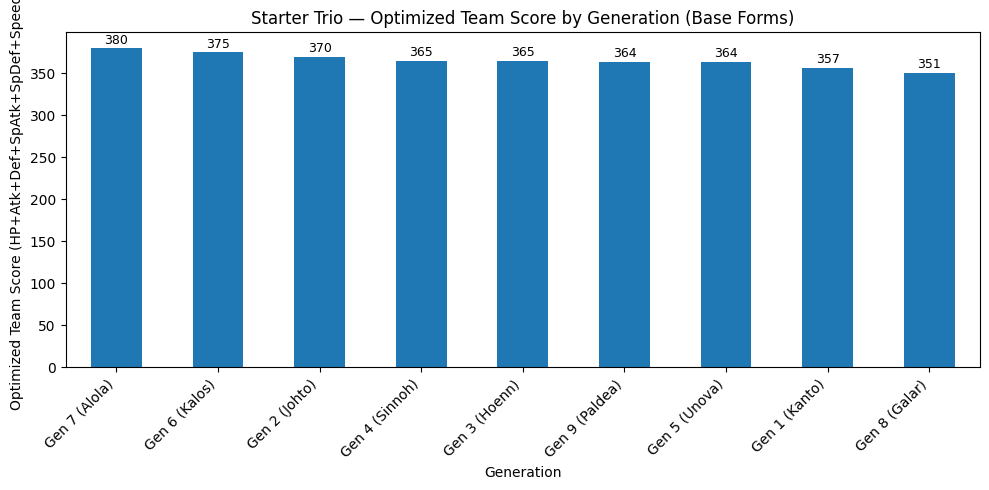

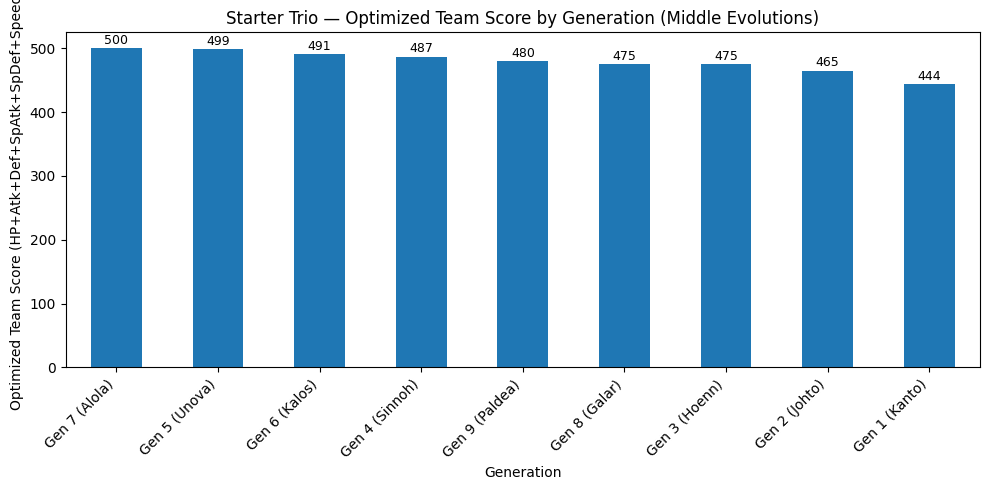

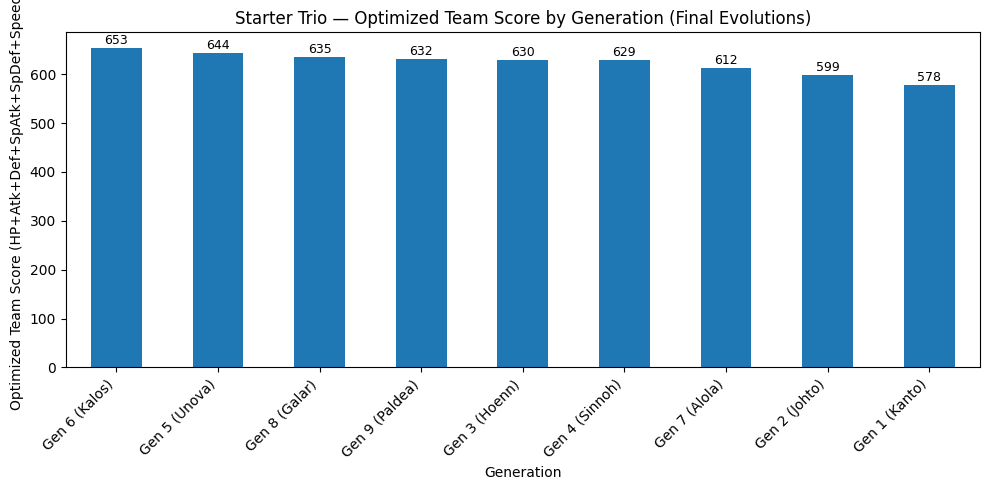

In [ ]:
plot_team_scores(best_base,   "Starter Trio — Optimized Team Score by Generation (Base Forms)")
plot_team_scores(best_middle, "Starter Trio — Optimized Team Score by Generation (Middle Evolutions)")
plot_team_scores(best_final,  "Starter Trio — Optimized Team Score by Generation (Final Evolutions)")


=== Average Optimized Team Scores Across All Stages ===


,Base,Middle,Final,Average
Gen 6 (Kalos),375,491,653,506.333333
Gen 5 (Unova),364,499,644,502.333333
Gen 7 (Alola),380,500,612,497.333333
Gen 4 (Sinnoh),365,487,629,493.666667
Gen 9 (Paldea),364,480,632,492.000000
Gen 3 (Hoenn),365,475,630,490.000000
Gen 8 (Galar),351,475,635,487.000000
Gen 2 (Johto),370,465,599,478.000000
Gen 1 (Kanto),357,444,578,459.666667


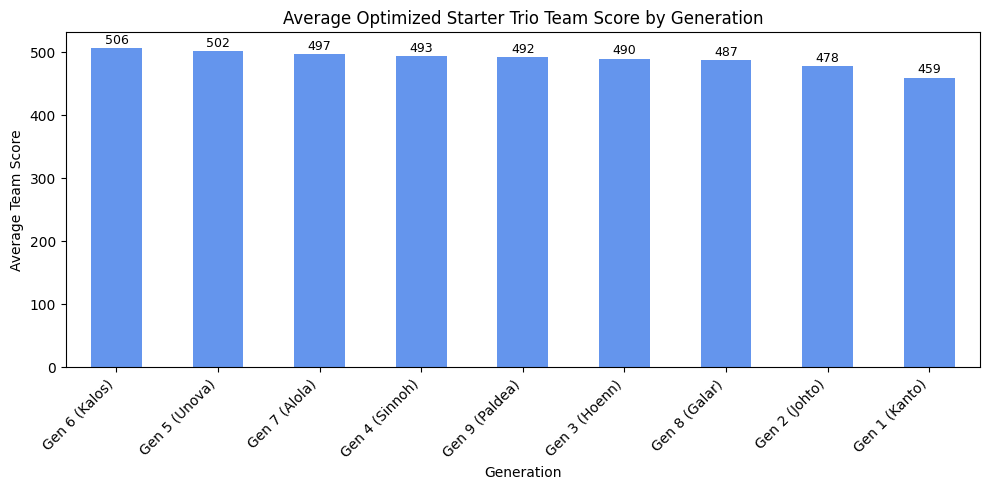

In [ ]:
# Combine team scores into one DataFrame
team_scores = pd.DataFrame({
    "Base": best_base["team_score"],
    "Middle": best_middle["team_score"],
    "Final": best_final["team_score"]
})

# Add average score column
team_scores["Average"] = team_scores.mean(axis=1)

# Sort by average (descending)
team_scores_sorted = team_scores.sort_values("Average", ascending=False)

# Display table
print("=== Average Optimized Team Scores Across All Stages ===")
display(team_scores_sorted)

# Plot ranked bar chart
plt.figure(figsize=(10,5))
team_scores_sorted["Average"].plot(kind="bar", color="cornflowerblue")
plt.title("Average Optimized Starter Trio Team Score by Generation")
plt.xlabel("Generation")
plt.ylabel("Average Team Score")
plt.xticks(rotation=45, ha="right")

# Annotate bars with exact values
for i, v in enumerate(team_scores_sorted["Average"].values):
    plt.text(i, v + 2, str(int(v)), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- Normalize columns so downstream code is stable ---
df.columns = [c.strip() for c in df.columns]
rename_map = {
    'Type 1': 'Type1',
    'type1': 'Type1',
    'Sp. Attack': 'Sp. Atk',
    'Sp. Defense': 'Sp. Def',
    'name': 'Name'
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

STAT_COLS = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']

# Ensure numeric stat columns
for col in STAT_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Compute Total if it's missing
if 'Total' not in df.columns and all(c in df.columns for c in STAT_COLS):
    df['Total'] = df[STAT_COLS].sum(axis=1)

# Drop rows without a primary type
df = df.dropna(subset=['Type1']).copy()

# --- Power trio selection ---
def select_power_trio(frame: pd.DataFrame) -> pd.DataFrame:
    work = frame.copy()
    work['Bulk_Score'] = work['HP'] + work['Defense'] + work['Sp. Def']
    work['Attack_Score'] = work[['Attack', 'Sp. Atk']].max(axis=1)

    strongest_attacker = work.loc[work['Attack_Score'].idxmax()]
    bulkiest = work.loc[work['Bulk_Score'].idxmax()]
    fastest = work.loc[work['Speed'].idxmax()]

    trio = pd.DataFrame([strongest_attacker, bulkiest, fastest])
    return trio.reset_index(drop=True)

final_trio = select_power_trio(df)

print("\nPower Trio (from CSV):\n")
print(final_trio[['Name', 'Type1', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Total']])

# --- Line Chart across stats ---
melted = final_trio.melt(
    id_vars=['Name', 'Type1'],
    value_vars=STAT_COLS,
    var_name='Stat',
    value_name='Value'
)

plt.figure(figsize=(10, 6))
for name in final_trio['Name']:
    subset = melted[melted['Name'] == name]
    plt.plot(subset['Stat'], subset['Value'], marker='o', label=name)

plt.title("Power Trio Stat Comparison")
plt.xlabel("Stats")
plt.ylabel("Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# --- Radar Chart ---
stats = STAT_COLS
angles = np.linspace(0, 2 * np.pi, len(stats), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(8, 8))
plt.subplot(polar=True)

for _, row in final_trio.iterrows():
    values = row[stats].tolist()
    values += values[:1]
    plt.plot(angles, values, marker='o', label=row['Name'])
    plt.fill(angles, values, alpha=0.1)

plt.xticks(angles[:-1], stats)
plt.title("Power Trio Radar Chart", size=15, y=1.08)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()




NameError: name 'df' is not defined